In [2]:
from astropy.io import fits
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.coordinates import Angle
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.wcs import WCS

In [3]:
data_folder = 'ADP_FLAMES_30Dor_30arcmin'

In [4]:
fits_dir = Path(r"C:\Users\javas\Dropbox\GitHub\VIENTO\structure_function_analysis\FLAMES_30Dor") / data_folder

In [7]:
from pathlib import Path
import pickle

base_dir = Path(r"C:\Users\javas\Dropbox\GitHub\VIENTO\structure_function_analysis\FLAMES_30Dor")
pickle_path = base_dir / "flames30dor_dataframes.pkl"

with open(pickle_path, "rb") as f:
    df_dict = pickle.load(f)

df = df_dict["df"]
df_letter = df_dict["df_letter"]
df_pos = df_dict["df_pos"]
df_stellar = df_dict["df_num"]

print(df_dict.keys())
print(df_letter.head())

dict_keys(['df', 'df_letter', 'df_pos', 'df_num'])
                              filename object                 date_obs  \
2336  ADP.2019-01-31T23_53_42.007.fits    t60  2003-12-03T03:42:56.961   
2337  ADP.2019-01-31T23_53_42.024.fits    t29  2003-12-03T05:54:18.706   
2338  ADP.2019-01-31T23_53_42.039.fits    u37  2003-12-03T01:44:39.244   
2339  ADP.2019-01-31T23_53_42.048.fits    t56  2003-12-03T01:44:39.244   
2341  ADP.2019-01-31T23_53_42.079.fits    u10  2003-12-03T03:42:56.961   

           mjd_obs instrument   telescope                           arcfile  \
2336  52976.154826    GIRAFFE  ESO-VLT-U2  ADP.2019-01-31T23:53:42.007.fits   
2337  52976.246050    GIRAFFE  ESO-VLT-U2  ADP.2019-01-31T23:53:42.024.fits   
2338  52976.072676    GIRAFFE  ESO-VLT-U2  ADP.2019-01-31T23:53:42.039.fits   
2339  52976.072676    GIRAFFE  ESO-VLT-U2  ADP.2019-01-31T23:53:42.048.fits   
2341  52976.154826    GIRAFFE  ESO-VLT-U2  ADP.2019-01-31T23:53:42.079.fits   

            prog_id          

# Stellar grid

In [9]:
df_stellar

,filename,object,date_obs,mjd_obs,instrument,telescope,arcfile,prog_id,pro_catg,dpr_catg,dpr_type,dpr_tech,ra_deg,dec_deg,EXPTIME,EXPTIME_round,sample_id,object_group
112,ADP.2019-01-30T02_54_20.891.fits,59272,2008-12-27T07:28:33.257,54827.311496,GIRAFFE,ESO-VLT-U2,ADP.2019-01-30T02:54:20.891.fits,182.D-0222(A),SCIENCE_RBNSPEC_STACK,None,None,None,84.910125,-68.976667,4530.0286,4530.0,59272_ra84.910125_dec-68.976667_exp4530.0,digits_only
113,ADP.2019-01-30T02_54_20.913.fits,48519,2008-12-27T07:28:33.257,54827.311496,GIRAFFE,ESO-VLT-U2,ADP.2019-01-30T02:54:20.913.fits,182.D-0222(A),SCIENCE_RBNSPEC_STACK,None,None,None,85.084500,-69.053306,4530.0286,4530.0,48519_ra85.0845_dec-69.053306_exp4530.0,digits_only
114,ADP.2019-01-30T02_54_20.917.fits,26852,2008-12-27T07:28:33.257,54827.311496,GIRAFFE,ESO-VLT-U2,ADP.2019-01-30T02:54:20.917.fits,182.D-0222(A),SCIENCE_RBNSPEC_STACK,None,None,None,84.926000,-69.224556,4530.0286,4530.0,26852_ra84.926_dec-69.224556_exp4530.0,digits_only
115,ADP.2019-01-30T02_54_20.937.fits,22089,2008-12-27T07:28:33.257,54827.311496,GIRAFFE,ESO-VLT-U2,ADP.2019-01-30T02:54:20.937.fits,182.D-0222(A),SCIENCE_RBNSPEC_STACK,None,None,None,84.663417,-69.258417,4530.0286,4530.0,22089_ra84.663417_dec-69.258417_exp4530.0,digits_only
116,ADP.2019-01-30T02_54_20.945.fits,42430,2008-12-27T07:28:33.257,54827.311496,GIRAFFE,ESO-VLT-U2,ADP.2019-01-30T02:54:20.945.fits,182.D-0222(A),SCIENCE_RBNSPEC_STACK,None,None,None,85.072917,-69.103806,4530.0286,4530.0,42430_ra85.072917_dec-69.103806_exp4530.0,digits_only
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3404,ADP.2019-05-15T10_50_10.633.fits,92597,2006-03-30T01:24:44.185,53824.058845,GIRAFFE,ESO-VLT-U2,ADP.2019-05-15T10:50:10.633.fits,076.D-0381(A),SCIENCE_RBNSPEC_IDP,None,None,None,85.802625,-69.007917,2769.9998,2770.0,92597_ra85.802625_dec-69.007917_exp2770.0,digits_only
3405,ADP.2019-05-15T10_50_10.635.fits,93392,2006-03-30T01:24:44.185,53824.058845,GIRAFFE,ESO-VLT-U2,ADP.2019-05-15T10:50:10.635.fits,076.D-0381(A),SCIENCE_RBNSPEC_IDP,None,None,None,86.062833,-69.135139,2769.9998,2770.0,93392_ra86.062833_dec-69.135139_exp2770.0,digits_only
3406,ADP.2019-05-15T10_50_10.637.fits,94958,2006-03-30T01:24:44.185,53824.058845,GIRAFFE,ESO-VLT-U2,ADP.2019-05-15T10:50:10.637.fits,076.D-0381(A),SCIENCE_RBNSPEC_IDP,None,None,None,86.125583,-69.206083,2769.9998,2770.0,94958_ra86.125583_dec-69.206083_exp2770.0,digits_only
3407,ADP.2019-05-15T10_50_10.643.fits,93013,2006-03-30T01:24:44.185,53824.058845,GIRAFFE,ESO-VLT-U2,ADP.2019-05-15T10:50:10.643.fits,076.D-0381(A),SCIENCE_RBNSPEC_IDP,None,None,None,85.942583,-69.239417,2769.9998,2770.0,93013_ra85.942583_dec-69.239417_exp2770.0,digits_only


# Plot data points

In [14]:
c0 = SkyCoord.from_name("Tarantula")
print(c0)

<SkyCoord (ICRS): (ra, dec) in deg
    (84.675, -69.1)>


In [16]:
ra0 = c0.ra.deg
dec0 = c0.dec.deg


In [17]:
c0 = SkyCoord.from_name("Tarantula")
print(c0)

#fov_deg = 1.0  # Total field of view in degrees (width and height)
#pix_scale = 1 / 3600
#npix = int(fov_deg / pix_scale)

# Create WCS for TAN projection centered at 'center'
wcs = WCS(naxis=2)
wcs.wcs.ctype = ["RA---TAN", "DEC--TAN"]
wcs.wcs.crval = [c0.ra.deg, c0.dec.deg]
#wcs.wcs.crpix = [npix, npix]  # center of your "image"
#wcs.wcs.cdelt = [-pix_scale, pix_scale]  # field size / pixel count

<SkyCoord (ICRS): (ra, dec) in deg
    (84.675, -69.1)>


In [24]:

centro = SkyCoord(ra=ra0*u.deg, dec=dec0*u.deg, frame='icrs')

coords = SkyCoord(
    ra=df_stellar["ra_deg"].values * u.deg,
    dec=df_stellar["dec_deg"].values * u.deg,
    frame='icrs'
)

radio = 1652/2 * u.arcsec   # por ejemplo
sep = coords.separation(centro)

df_stellar= df_stellar[sep <= radio]

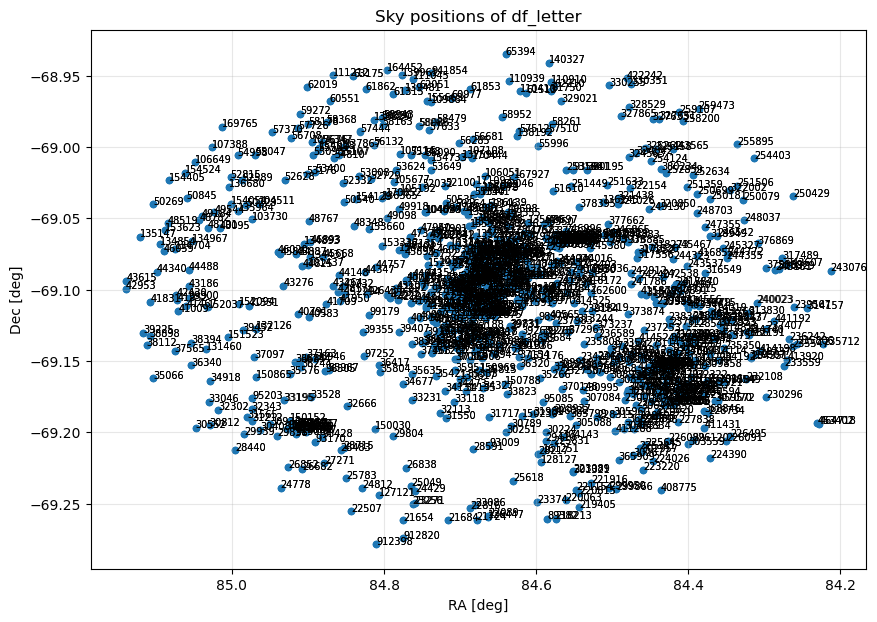

In [29]:
df_plot = df_stellar.dropna(subset=["ra_deg", "dec_deg"]).copy()

plt.figure(figsize=(10, 7))
plt.scatter(df_plot["ra_deg"], df_plot["dec_deg"], s=20)

for _, row in df_plot.iterrows():
    label = row["object"] if pd.notna(row["object"]) and row["object"] else row["filename"]
    plt.text(row["ra_deg"], row["dec_deg"], label, fontsize=7)

plt.xlabel("RA [deg]")
plt.ylabel("Dec [deg]")
plt.title("Sky positions of df_letter")
plt.gca().invert_xaxis()
plt.grid(True, alpha=0.3)
plt.show()

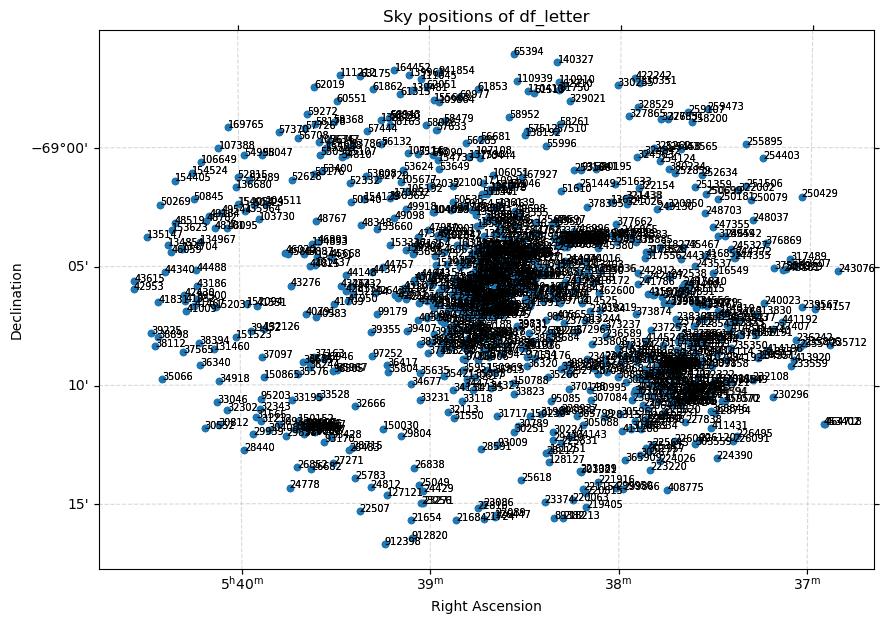

In [27]:
df_plot = df_stellar.dropna(subset=["ra_deg", "dec_deg"]).copy()

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(1, 1, 1, projection=wcs)

ax.scatter(
    df_plot["ra_deg"],
    df_plot["dec_deg"],
    s=20,
    transform=ax.get_transform("world")
)

for _, row in df_plot.iterrows():
    label = row["object"] if pd.notna(row["object"]) and row["object"] else row["filename"]
    ax.text(
        row["ra_deg"],
        row["dec_deg"],
        label,
        fontsize=7,
        transform=ax.get_transform("world")
    )

ax.set_title("Sky positions of df_letter")
ax.coords[0].set_axislabel("Right Ascension")
ax.coords[1].set_axislabel("Declination")
ax.grid(color="gray", alpha=0.3, linestyle="--")
plt.gca().invert_xaxis()

plt.show()

Load spetra

In [31]:
from pathlib import Path
from astropy.io import fits

# Folder where the FITS files are stored

stellar_spectra = []

for _, row in  df_stellar.iterrows():
    fits_path = fits_dir / row["filename"]

    try:
        with fits.open(fits_path) as hdul:
            spec = hdul[1].data

            wave = spec["WAVE"][0]
            flux = spec["FLUX_REDUCED"][0]
            err  = spec["ERR_REDUCED"][0]
#            snr  = spec["SNR"][0]

            stellar_spectra.append({
                "filename": row["filename"],
                "object": row["object"],
                "ra_deg": row["ra_deg"],
                "dec_deg": row["dec_deg"],
                "wave": wave,
                "flux": flux,
                "err": err,
#                "snr": snr,
            })

    except Exception as e:
        print(f"Could not read {fits_path.name}: {e}")

print(f"Loaded {len(stellar_spectra)} spectra from df_stellar")

Loaded 2000 spectra from df_stellar


In [11]:
def plot_spectra_subset(spectra_list, wmin, wmax, normalize=False):
    plt.figure(figsize=(12, 6))

    for spec in spectra_list:
        wave = spec["wave"]
        flux = spec["flux"]
        mask = (wave >= wmin) & (wave <= wmax)

        wave_zoom = wave[mask]
        flux_zoom = flux[mask]

        if len(wave_zoom) == 0:
            continue

        if normalize and flux_zoom.max() != 0:
            flux_zoom = flux_zoom / flux_zoom.max()

        plt.plot(wave_zoom, flux_zoom, alpha=0.7, lw=1)

    plt.xlabel("Wavelength [nm]")
    plt.ylabel("Normalized Flux" if normalize else "Reduced Flux [adu]")
    plt.title(f"Spectra zoom: {wmin}–{wmax} nm")
    plt.grid(True, alpha=0.3)
    plt.show()

In [12]:
#letter_spectra

In [13]:
#plot_spectra_subset(letter_spectra, 655, 658, normalize=True)

Export one PNG per spectrum

Script for one object family.

In [19]:
# Sample EXPTIME

In [33]:
df_stellar["EXPTIME"].value_counts().sort_index()

EXPTIME
4530.0191    111
4530.0202    112
4530.0209    112
4530.0229    220
4530.0231    109
4530.0232    220
4530.0233    111
4530.0234    111
4530.0237    113
4530.0238    113
4530.0242    111
4530.0243    113
4530.0244    109
4530.0253    113
4530.0270    111
4530.0286    111
Name: count, dtype: int64

# Sample exposure time

In [40]:
df_expA = df_stellar[df_stellar["EXPTIME"] == 4530.0191].copy()
df_expB = df_stellar[df_stellar["EXPTIME"] == 4530.0202].copy()
df_expC = df_stellar[df_stellar["EXPTIME"] == 4530.0209].copy()
df_expD = df_stellar[df_stellar["EXPTIME"] == 4530.0229].copy()
df_expE = df_stellar[df_stellar["EXPTIME"] == 4530.0231].copy()
df_expF = df_stellar[df_stellar["EXPTIME"] == 4530.0232].copy()
df_expG = df_stellar[df_stellar["EXPTIME"] == 4530.0233].copy()
df_expH = df_stellar[df_stellar["EXPTIME"] == 4530.0234].copy()
df_expI = df_stellar[df_stellar["EXPTIME"] == 4530.0237].copy()
df_expJ = df_stellar[df_stellar["EXPTIME"] == 4530.0238].copy()
df_expK = df_stellar[df_stellar["EXPTIME"] == 4530.0242].copy()
df_expL = df_stellar[df_stellar["EXPTIME"] == 4530.0243].copy()
df_expM = df_stellar[df_stellar["EXPTIME"] == 4530.0244].copy()
df_expN = df_stellar[df_stellar["EXPTIME"] == 4530.0253].copy()
df_expO = df_stellar[df_stellar["EXPTIME"] == 4530.0270].copy()
df_expP = df_stellar[df_stellar["EXPTIME"] == 4530.0286].copy()

In [41]:
df_plotA = df_expA.dropna(subset=["ra_deg", "dec_deg"]).copy()
df_plotB = df_expB.dropna(subset=["ra_deg", "dec_deg"]).copy()
df_plotC = df_expC.dropna(subset=["ra_deg", "dec_deg"]).copy()
df_plotD = df_expD.dropna(subset=["ra_deg", "dec_deg"]).copy()
df_plotE = df_expE.dropna(subset=["ra_deg", "dec_deg"]).copy()
df_plotF = df_expF.dropna(subset=["ra_deg", "dec_deg"]).copy()
df_plotG = df_expG.dropna(subset=["ra_deg", "dec_deg"]).copy()
df_plotH = df_expH.dropna(subset=["ra_deg", "dec_deg"]).copy()
df_plotI = df_expI.dropna(subset=["ra_deg", "dec_deg"]).copy()
df_plotJ = df_expJ.dropna(subset=["ra_deg", "dec_deg"]).copy()
df_plotK = df_expK.dropna(subset=["ra_deg", "dec_deg"]).copy()
df_plotL = df_expL.dropna(subset=["ra_deg", "dec_deg"]).copy()
df_plotM = df_expM.dropna(subset=["ra_deg", "dec_deg"]).copy()
df_plotN = df_expN.dropna(subset=["ra_deg", "dec_deg"]).copy()
df_plotO = df_expO.dropna(subset=["ra_deg", "dec_deg"]).copy()
df_plotP = df_expP.dropna(subset=["ra_deg", "dec_deg"]).copy()

In [42]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_sky_positions(df_plot, wcs, title="Sky positions", color="blue", marker="s", size=20, fontsize=7):
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(1, 1, 1, projection=wcs)

    ax.scatter(
        df_plot["ra_deg"],
        df_plot["dec_deg"],
        s=size,
        marker=marker,
        color=color,
        transform=ax.get_transform("world")
    )

    for _, row in df_plot.iterrows():
        label = row["object"] if pd.notna(row["object"]) and row["object"] else row["filename"]
        ax.text(
            row["ra_deg"],
            row["dec_deg"],
            label,
            fontsize=fontsize,
            transform=ax.get_transform("world")
        )

    ax.set_title(title)
    ax.coords[0].set_axislabel("Right Ascension")
    ax.coords[1].set_axislabel("Declination")
    ax.grid(color="gray", alpha=0.3, linestyle="--")
    ax.invert_xaxis()

    plt.show()

In [43]:
dfs = {
    "A": df_plotA,
    "B": df_plotB,
    "C": df_plotC,
    "D": df_plotD,
    "E": df_plotE,
    "F": df_plotF,
    "G": df_plotG,
    "H": df_plotH,
    "I": df_plotI,
    "J": df_plotJ,
    "K": df_plotK,
    "L": df_plotL,
    "M": df_plotM,
    "N": df_plotN,
    "O": df_plotO,
    "P": df_plotP,
}

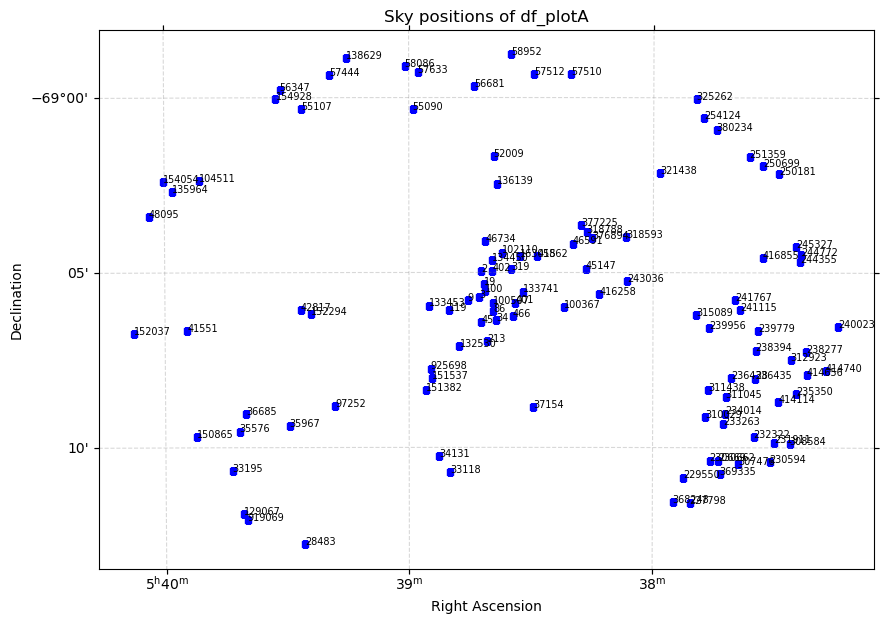

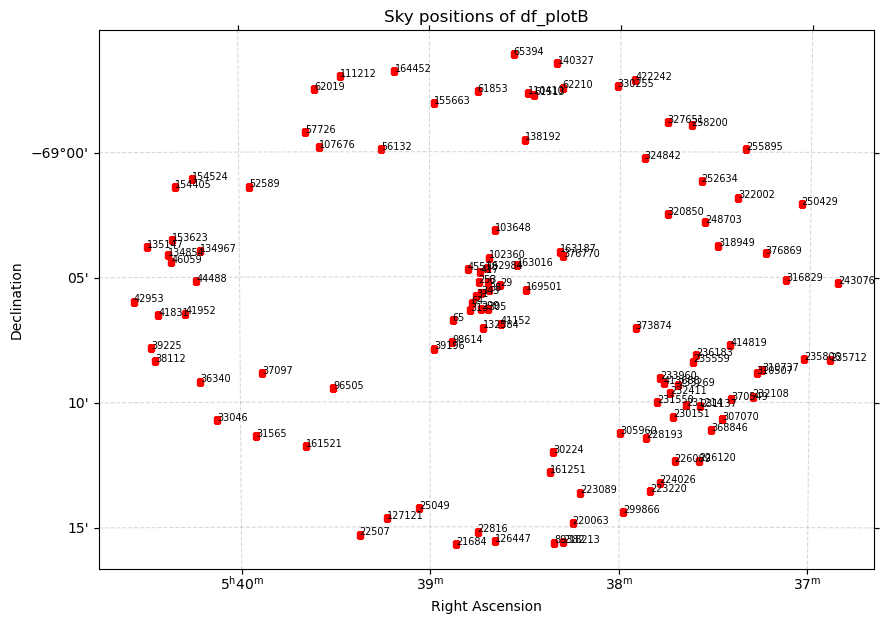

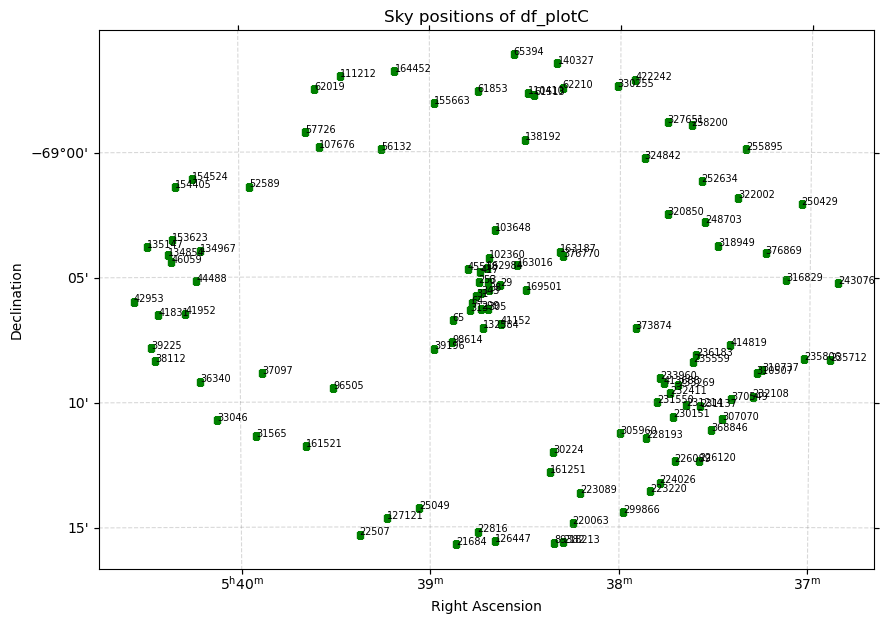

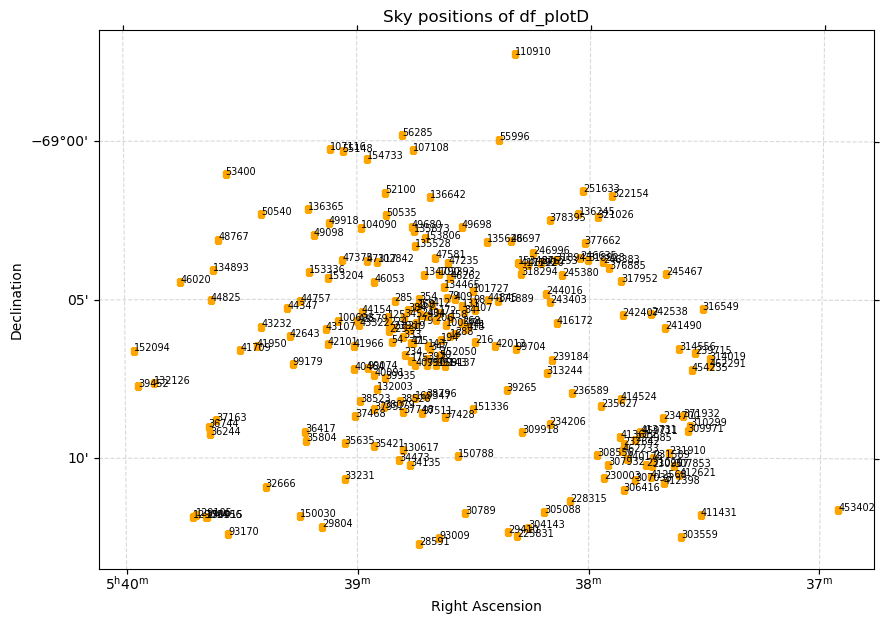

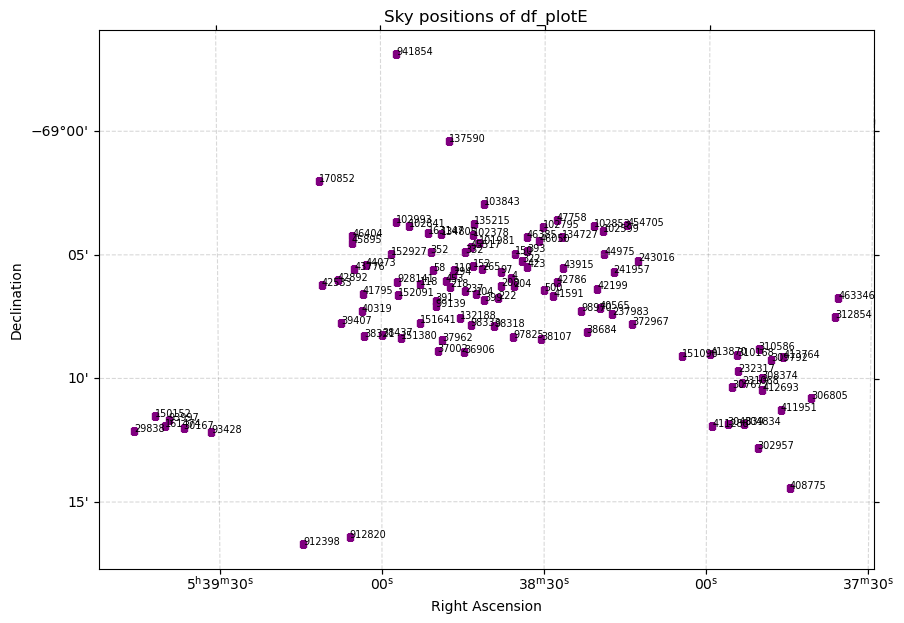

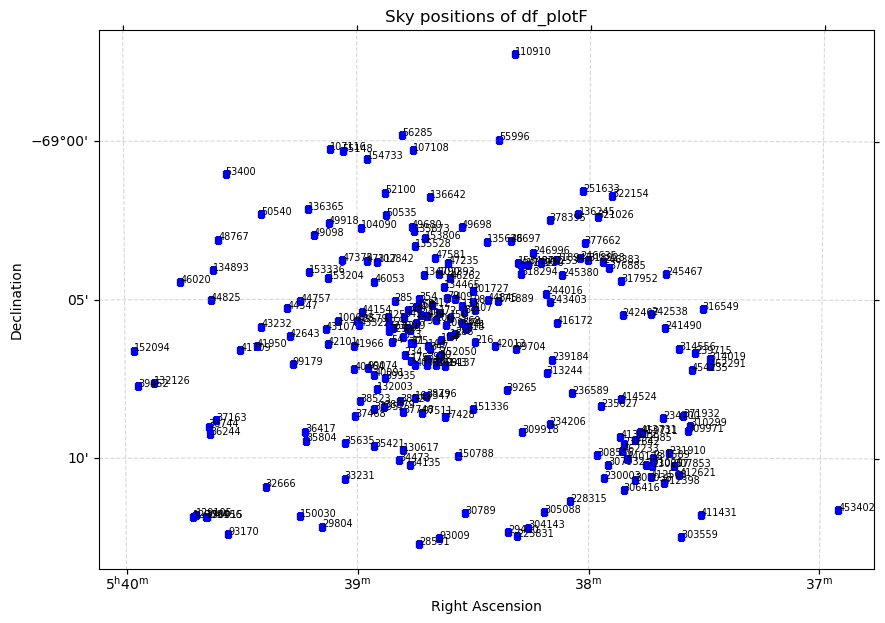

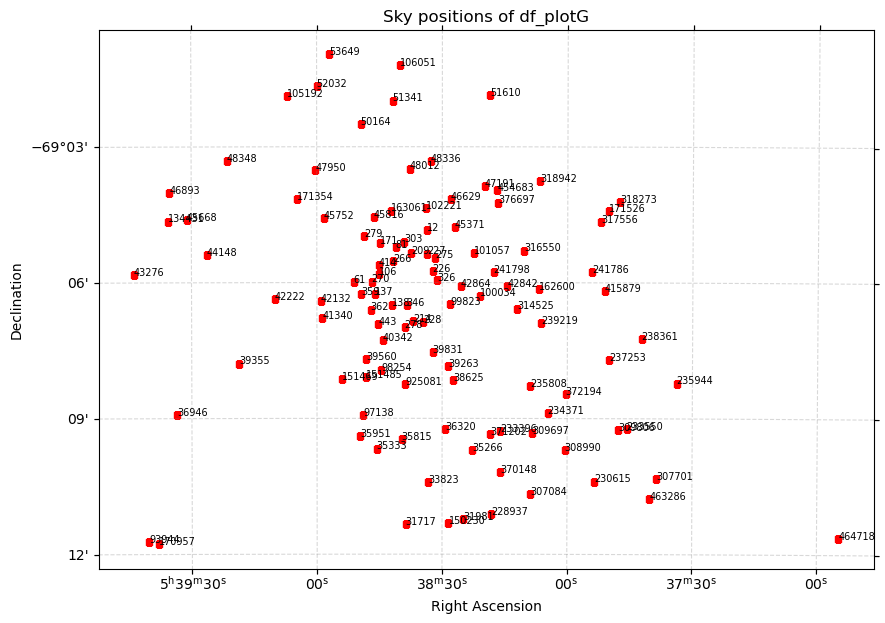

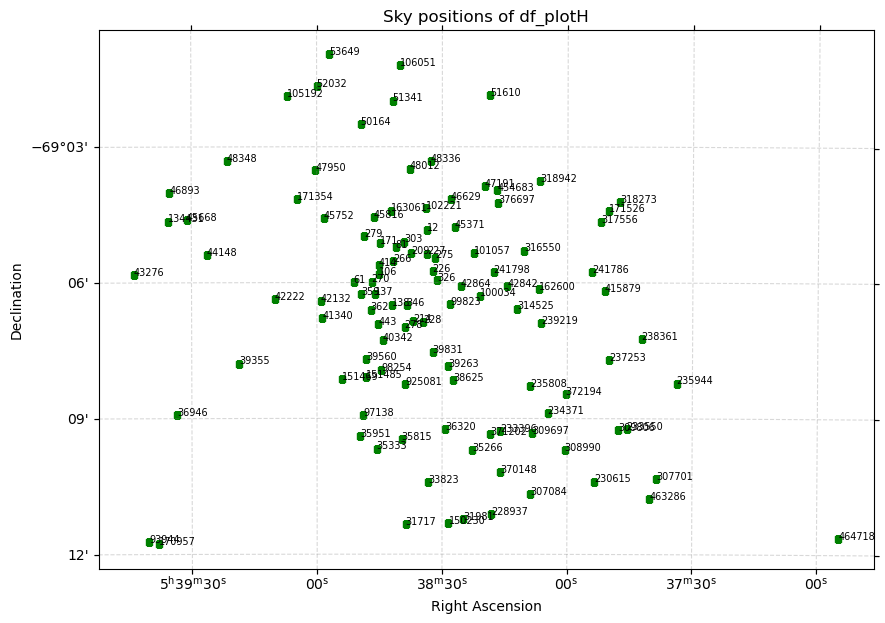

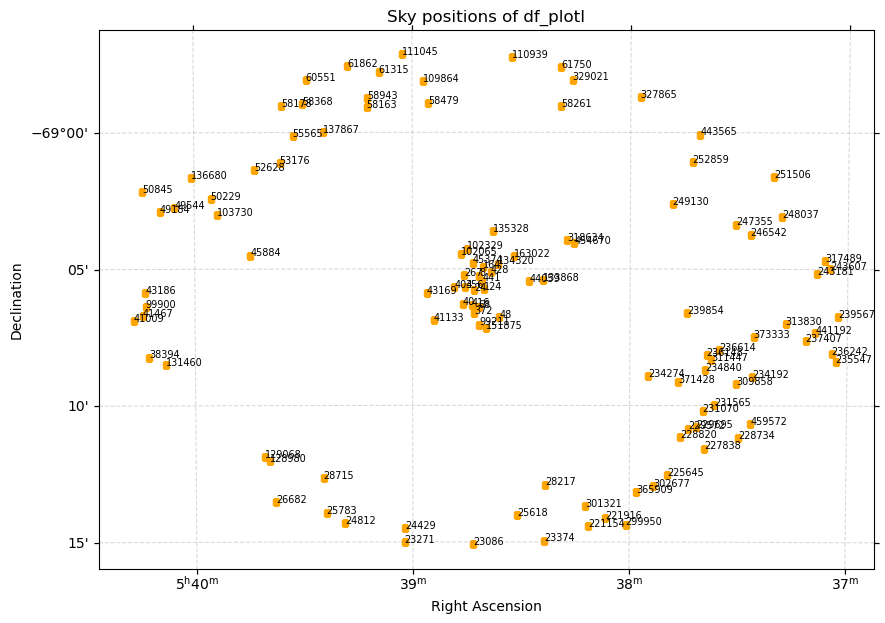

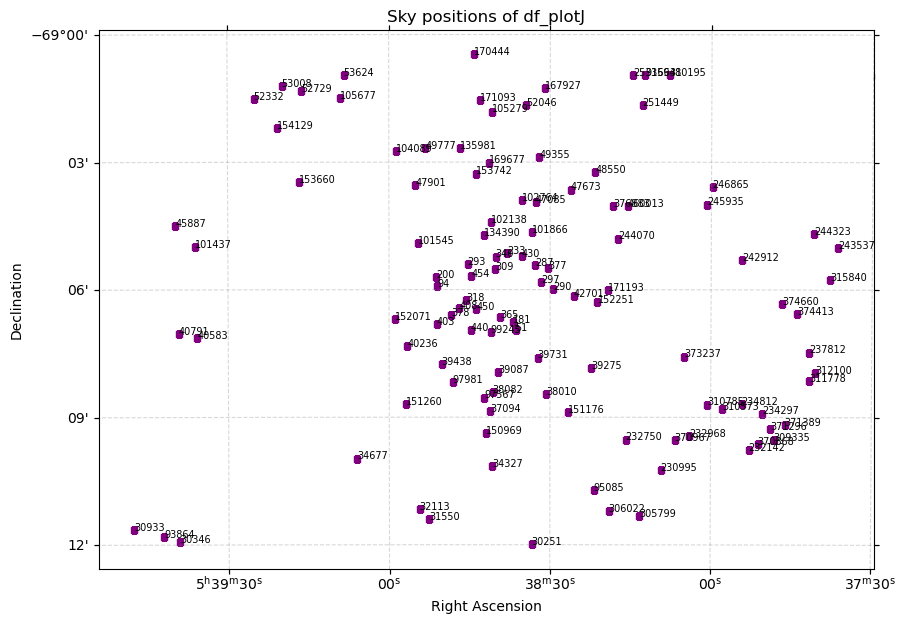

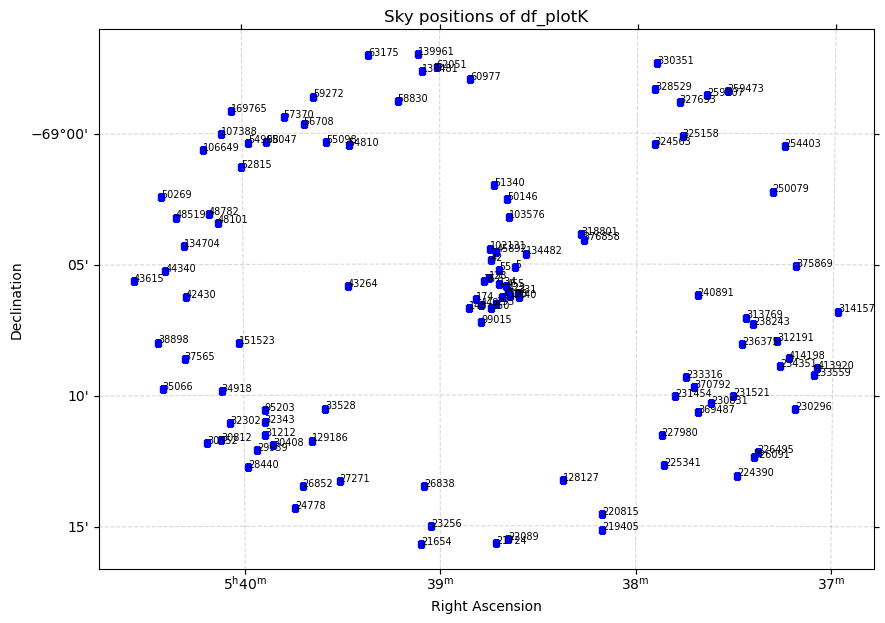

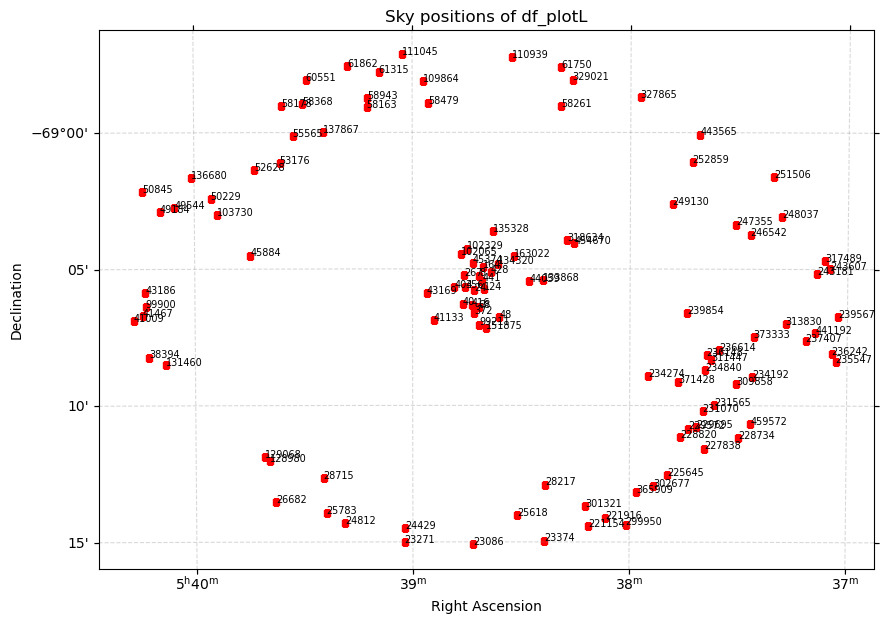

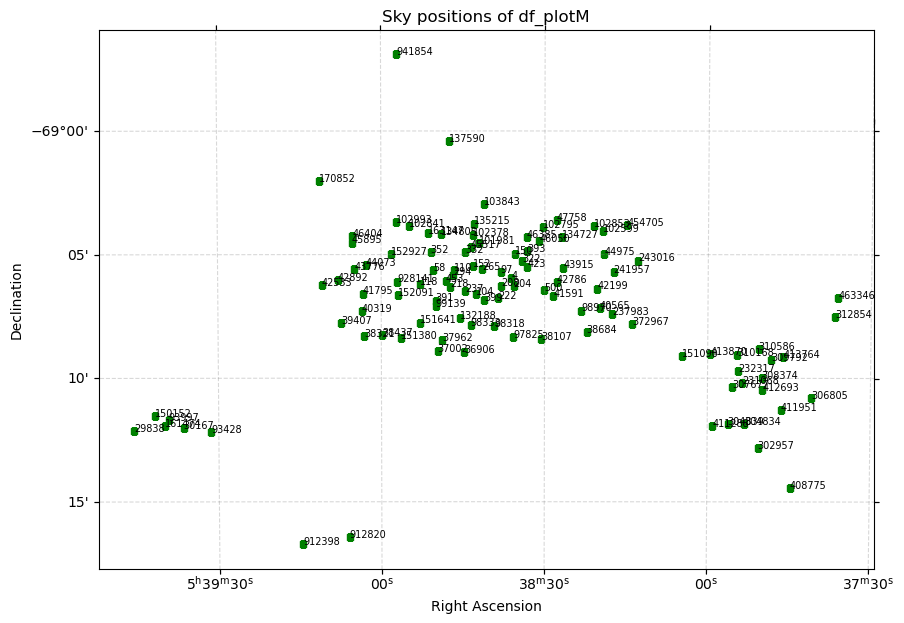

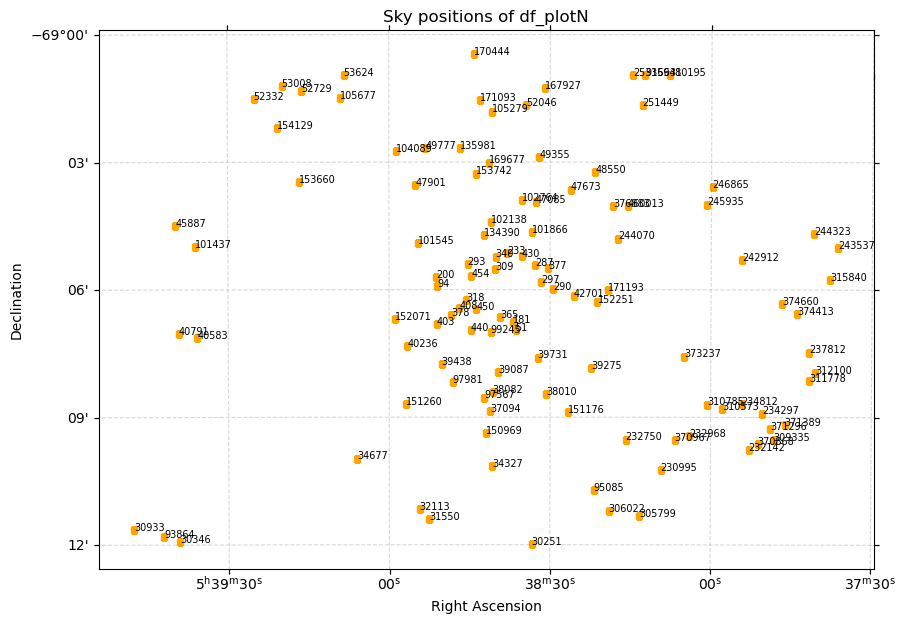

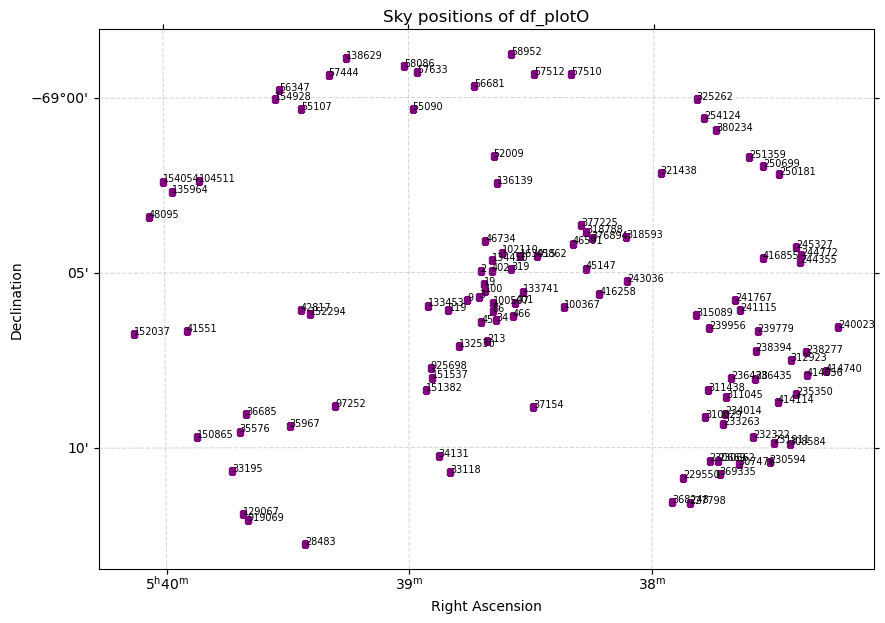

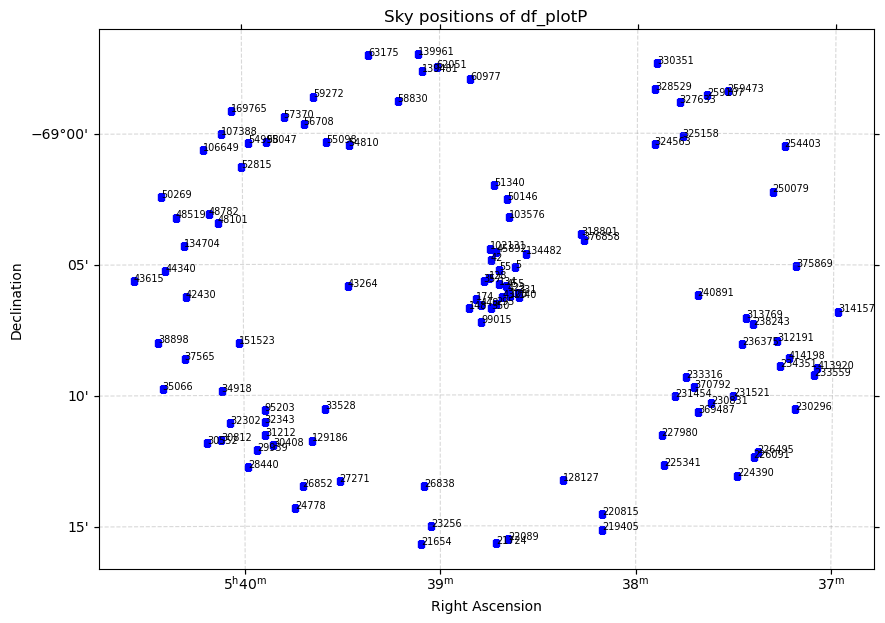

In [44]:
colors = ["blue", "red", "green", "orange", "purple",
          "blue", "red", "green", "orange", "purple",
          "blue", "red", "green", "orange", "purple",
          "blue"
         ]

for (name, df_plot), color in zip(dfs.items(), colors):
    plot_sky_positions(df_plot, wcs, title=f"Sky positions of df_plot{name}", color=color)

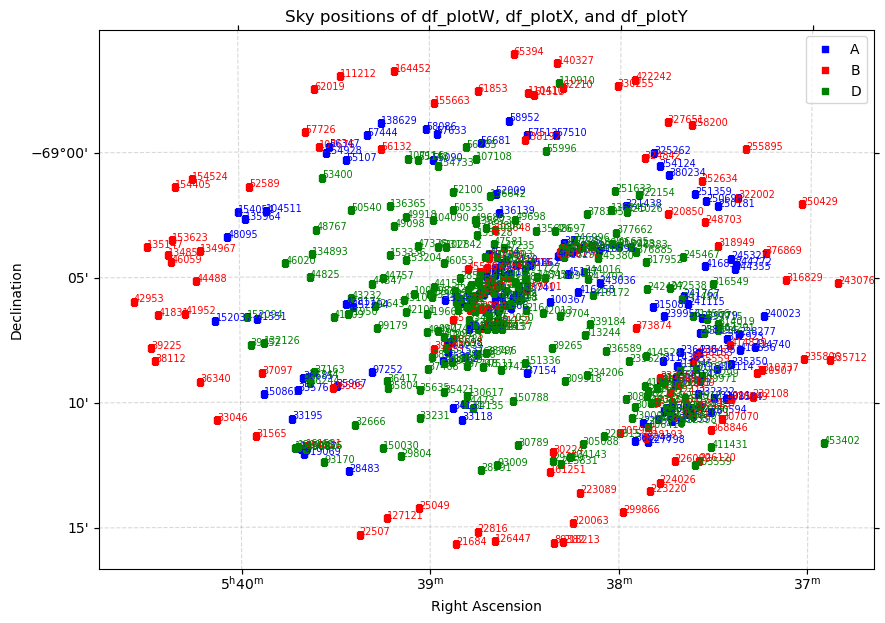

In [46]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(1, 1, 1, projection=wcs)

dfs = {
    "A": (df_plotA, "blue"),
    "B": (df_plotB, "red"),
    "D": (df_plotD, "green"),
}

for name, (df_plot, color) in dfs.items():
    ax.scatter(
        df_plot["ra_deg"],
        df_plot["dec_deg"],
        s=20,
        marker="s",
        color=color,
        label=name,
        transform=ax.get_transform("world")
    )

    for _, row in df_plot.iterrows():
        label = row["object"] if pd.notna(row["object"]) and row["object"] else row["filename"]
        ax.text(
            row["ra_deg"],
            row["dec_deg"],
            label,
            fontsize=7,
            color=color,
            transform=ax.get_transform("world")
        )

ax.set_title("Sky positions of df_plotW, df_plotX, and df_plotY")
ax.coords[0].set_axislabel("Right Ascension")
ax.coords[1].set_axislabel("Declination")
ax.grid(color="gray", alpha=0.3, linestyle="--")
ax.legend()

ax.invert_xaxis()
plt.show()

# Data EXPTIME samples

Load spectra

In [47]:
from pathlib import Path
from astropy.io import fits
import pandas as pd

def load_spectra_from_df(df, fits_dir, flux_col="FLUX_REDUCED", err_col="ERR_REDUCED"):
    spectra = []

    for _, row in df.iterrows():
        fits_path = fits_dir / row["filename"]

        try:
            with fits.open(fits_path) as hdul:
                spec = hdul[1].data

                wave = spec["WAVE"][0]
                flux = spec[flux_col][0]
                err  = spec[err_col][0]

                spectra.append({
                    "filename": row["filename"],
                    "object": row["object"],
                    "ra_deg": row["ra_deg"],
                    "dec_deg": row["dec_deg"],
                    "wave": wave,
                    "flux": flux,
                    "err": err,
                })

        except Exception as e:
            print(f"Could not read {fits_path.name}: {e}")

    print(f"Loaded {len(spectra)} spectra")
    return spectra

In [48]:
dfs_exp = {
    "A": df_expA,
    "B": df_expB,
    "C": df_expC,
    "D": df_expD,
    "E": df_expE,
    "F": df_expF,
    "G": df_expG,
    "H": df_expH,
    "I": df_expI,
    "J": df_expJ,
    "K": df_expK,
    "L": df_expL,
    "M": df_expM,
    "N": df_expN,
    "O": df_expO,
    "P": df_expP
}

In [49]:
spectra_dict = {}

for name, df in dfs_exp.items():
    print(f"\nLoading spectra for group {name}")
    spectra_dict[name] = load_spectra_from_df(df, fits_dir)


Loading spectra for group A
Loaded 111 spectra

Loading spectra for group B
Loaded 112 spectra

Loading spectra for group C
Loaded 112 spectra

Loading spectra for group D
Loaded 220 spectra

Loading spectra for group E
Loaded 109 spectra

Loading spectra for group F
Loaded 220 spectra

Loading spectra for group G
Loaded 111 spectra

Loading spectra for group H
Loaded 111 spectra

Loading spectra for group I
Loaded 113 spectra

Loading spectra for group J
Loaded 113 spectra

Loading spectra for group K
Loaded 111 spectra

Loading spectra for group L
Loaded 113 spectra

Loading spectra for group M
Loaded 109 spectra

Loading spectra for group N
Loaded 113 spectra

Loading spectra for group O
Loaded 111 spectra

Loading spectra for group P
Loaded 111 spectra


In [52]:
def save_zoom_plots(spectra, outdir_name, wmin=655, wmax=658):
    outdir = Path(outdir_name)
    outdir.mkdir(exist_ok=True)

    for spec in spectra:
        wave = spec["wave"]
        flux = spec["flux"]
        mask = (wave >= wmin) & (wave <= wmax)

        fig, ax = plt.subplots(figsize=(10, 5))
        ax.plot(wave[mask], flux[mask])
        ax.set_xlabel("Wavelength [nm]")
        ax.set_ylabel("Reduced Flux [adu]")
        ax.set_title(f"{spec['object']} | {spec['filename']} | {wmin}–{wmax} nm")
        ax.grid(True, alpha=0.3)

        obj = str(spec["object"]).replace("/", "_").replace("\\", "_").replace(" ", "_")
        base = Path(spec["filename"]).stem
        fname = outdir / f"{obj}_{base}_{wmin}_{wmax}.png"

        fig.savefig(fname, dpi=200, bbox_inches="tight")
        plt.close(fig)

    print(f"Saved {len(spectra)} plots in: {outdir.resolve()}")
    plt.ioff()

In [53]:
dfs_export = {
    "A": spectra_dict['A'],
    "B": spectra_dict['B'],
    "C": spectra_dict['C'],
    "D": spectra_dict['D'],
    "E": spectra_dict['E'],
    "F": spectra_dict['F'],
    "G": spectra_dict['G'],
    "H": spectra_dict['H'],
    "I": spectra_dict['I'],
    "J": spectra_dict['J'],
    "K": spectra_dict['K'],
    "L": spectra_dict['L'],
    "M": spectra_dict['M'],
    "N": spectra_dict['N'],
    "O": spectra_dict['O'],
    "P": spectra_dict['P']
}

In [54]:
#for name, spectra in dfs_export.items():
#    save_zoom_plots(spectra, f"plots_stellar_zoom_{name}", wmin=655, wmax=658)

Saved 111 plots in: C:\Users\javas\Dropbox\GitHub\VIENTO\structure_function_analysis\FLAMES_30dor\plots_stellar_zoom_A
Saved 112 plots in: C:\Users\javas\Dropbox\GitHub\VIENTO\structure_function_analysis\FLAMES_30dor\plots_stellar_zoom_B
Saved 112 plots in: C:\Users\javas\Dropbox\GitHub\VIENTO\structure_function_analysis\FLAMES_30dor\plots_stellar_zoom_C
Saved 220 plots in: C:\Users\javas\Dropbox\GitHub\VIENTO\structure_function_analysis\FLAMES_30dor\plots_stellar_zoom_D
Saved 109 plots in: C:\Users\javas\Dropbox\GitHub\VIENTO\structure_function_analysis\FLAMES_30dor\plots_stellar_zoom_E
Saved 220 plots in: C:\Users\javas\Dropbox\GitHub\VIENTO\structure_function_analysis\FLAMES_30dor\plots_stellar_zoom_F
Saved 111 plots in: C:\Users\javas\Dropbox\GitHub\VIENTO\structure_function_analysis\FLAMES_30dor\plots_stellar_zoom_G
Saved 111 plots in: C:\Users\javas\Dropbox\GitHub\VIENTO\structure_function_analysis\FLAMES_30dor\plots_stellar_zoom_H
Saved 113 plots in: C:\Users\javas\Dropbox\GitHu